# MAQT & Proposition-2 Quantities: $F_{\mathrm{in}}$, $F_{\mathrm{out}}$, $\varepsilon^\star$
## BoT-IoT | Reuse Day-16 Checkpoint | Target (y) = "label_multiclass" | Data Reupload = 2 | All X_Zero Samples (Off 2000)

### Scope:

This notebook measures **Proposition-2 geometry** on the frozen MAQT encoder:
- load $\theta^\star$, class prototypes $\rho_c$, and $L_\varphi$
- encode known-test / zero-day samples to post-channel states $\rho(x)=\Lambda_p(U(\theta)|\psi(x)\rangle\langle\psi(x)|U(\theta)^\dagger)$
- report $F_{\mathrm{in}}$, $F_{\mathrm{out}}$, gap $\Delta$, and predicted budget $\varepsilon^\star$

### To Implement:

$$
\varepsilon^\star
= \frac{(1-F_{\mathrm{out}}) - \sqrt{1-F_{\mathrm{in}}^{2}}}{2(1-p)\,L_\varphi}
= \frac{\Delta}{2(1-p)\,L_\varphi}
$$

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_LR, DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, DEFAULT_NOISE_RATE,
    DEFAULT_CF, DEFAULT_EPS,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.theory import (
    collect_known_fidelities,
    f_max_batch,
    proposition2_gap,
    proposition2_epsilon_star_from_gap,
)
from scripts.utils import get_torch_device, to_np_y
from scripts.logging import write_history_log
from scripts.prototypes import prototype_summary

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: BoT-IoT

In [4]:
NOTEBOOK_NAME = "18.fin-fout-epsstar_bot-iot"
DAY16_NOTEBOOK = "16.estimate-lipschitz_bot-iot"
dataset = "BoT-IoT"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0000,0.295669,0.000000,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0000,0.404791,0.000000,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0000,0.458797,0.000000,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0000,0.186546,0.000000,0.483341,0.186546,DoS,1,dos
...,...,...,...,...,...,...,...,...,...,...,...
130133,0.051554,0.337622,0.054277,0.0000,0.109122,0.000000,0.401096,0.109122,DDoS,1,ddos
130134,0.077777,0.495858,0.081885,0.0000,0.482215,0.000000,0.555750,0.482215,DDoS,1,ddos
130135,0.085139,0.332164,0.089636,0.0000,0.295669,0.000000,0.395761,0.295669,DDoS,1,ddos
130136,0.034507,0.527890,0.036329,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0000,0.295669,0.000000,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0000,0.404791,0.000000,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0000,0.458797,0.000000,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0000,0.186546,0.000000,0.483341,0.186546,DoS,1,dos
...,...,...,...,...,...,...,...,...,...,...,...
130133,0.051554,0.337622,0.054277,0.0000,0.109122,0.000000,0.401096,0.109122,DDoS,1,ddos
130134,0.077777,0.495858,0.081885,0.0000,0.482215,0.000000,0.555750,0.482215,DDoS,1,ddos
130135,0.085139,0.332164,0.089636,0.0000,0.295669,0.000000,0.395761,0.295669,DDoS,1,ddos
130136,0.034507,0.527890,0.036329,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['DDoS', 'DoS', 'Normal', 'Reconnaissance']

In [8]:
# load full dataset (known classes only)
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_test, y_test = load_split(data_path, f"{split_prefix}_test", target_col, class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape]

[(130138, 8), (130138,), (18591, 8), (18591,)]

## EDA (Before Subset)

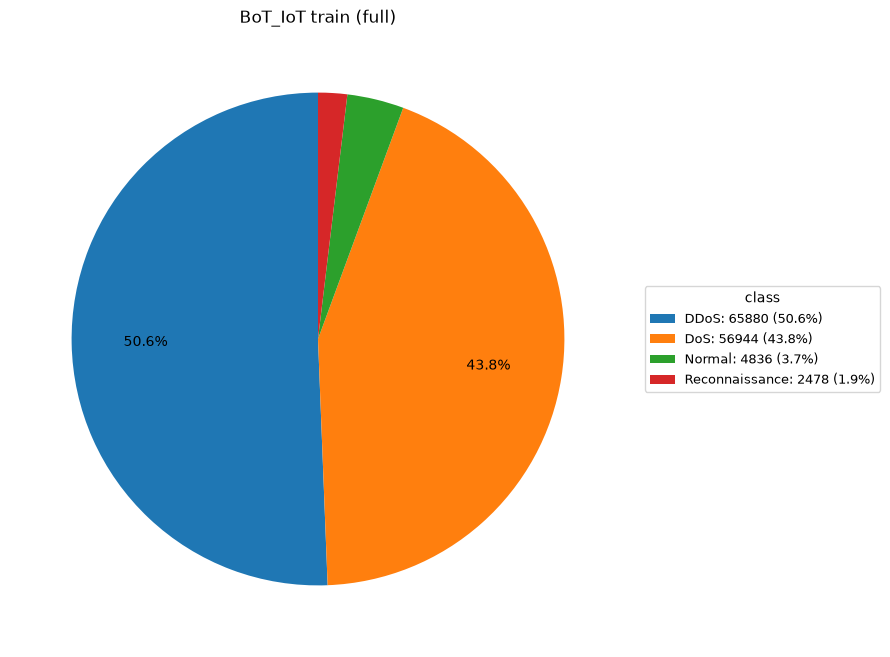

In [10]:
# pie chart
_ = plot_class_balance_pie(y_train_full, class_names, title=f"{dataset} train (full)")
plt.show()

## Data Subset

In [11]:
SUBSET = True  # set to False for the full dataset
SEED = 42
PER_CLASS_CAP = 700  # matches Day-16 BoT-IoT protocol

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(2800, 8), (2800,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 4
number of qubits: 8


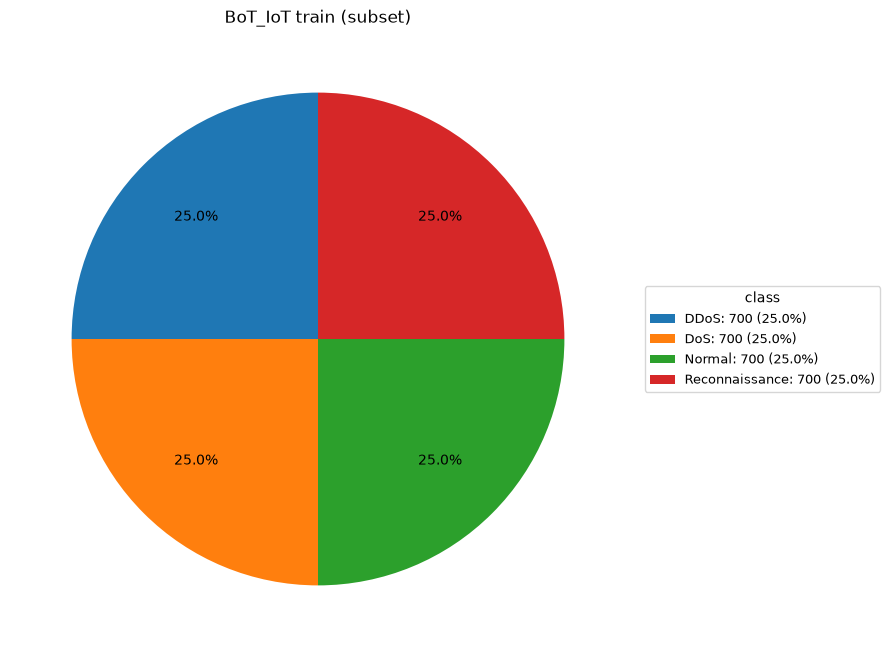

In [14]:
# pie chart
_ = plot_class_balance_pie(y_train, class_names, title=f"{dataset} train (subset)" if SUBSET else f"{dataset} train")
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [15]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Load Day-16 Encoder + $L_\varphi$

This notebook reuses the Day-16 MAQT checkpoint ($\theta^\star$, prototypes) and the published $L_\varphi$ artifact.

Set `LOAD_CHECKPOINT = False` only to retrain as a fallback.

In [17]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY16_NOTEBOOK}-checkpoint.pt",
]
LPHI_CANDIDATES = [
    Path("models/prototypes") / dataset / f"{DAY16_NOTEBOOK}-lphi.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2
Cf = DEFAULT_CF

In [18]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
lphi_path = next((p for p in LPHI_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))

    # rebuild circuit if checkpoint meta differs
    forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train, y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

loaded checkpoint: models/prototypes/BoT-IoT/16.estimate-lipschitz_bot-iot-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 4


In [19]:
# load Day-16 L_phi (required for eps*)
if lphi_path is not None:
    lphi_art = torch.load(lphi_path, map_location="cpu", weights_only=False)
    L_phi_estimated = float(lphi_art["L_phi_estimated"])
    L_phi_percentile = float(lphi_art.get("L_phi_percentile", 95.0))
    L_phi_analytic = float(lphi_art.get("L_phi_analytic", float("nan")))
    print(f"loaded L_phi from: {lphi_path}")
    print(f"L_phi (p{L_phi_percentile:g}): {L_phi_estimated:.4f}")
    print(f"L_phi (analytic): {L_phi_analytic:.4f}")    
else:
    raise FileNotFoundError(
        f"Day-16 L_phi artifact not found under models/prototypes/{dataset}/. "
        "Run 16.estimate-lipschitz_ciciot2023.ipynb first."
    )

loaded L_phi from: models/prototypes/BoT-IoT/16.estimate-lipschitz_bot-iot-lphi.pt
L_phi (p95): 0.6792
L_phi (analytic): 1.0000


## Load Zero-Day Split

$F_{\mathrm{out}}$ uses max fidelity of each zero-day state to the known prototypes only.

In [20]:
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,1.930101,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
1,1.964597,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
2,1.969794,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
3,1.391540,0.612713,1.299625,0.484059,0.482215,1.090129,0.515005,0.337155,Theft,1,theft_exfiltration
4,2.079034,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
...,...,...,...,...,...,...,...,...,...,...,...
678,1.254680,0.911693,1.181002,0.434803,0.458797,0.947530,0.950762,0.337155,Theft,1,theft_exfiltration
679,2.269998,0.408790,2.170553,0.374519,0.337155,0.904365,0.340159,0.186546,Theft,1,theft_exfiltration
680,1.816860,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
681,0.422707,0.951819,0.292256,0.809323,0.777883,1.401536,0.784051,0.575954,Theft,1,theft_exfiltration


In [21]:
feature_cols = [c for c in df_zero.columns if not c.startswith("label")]
X_zero_full = df_zero[feature_cols].values.astype(np.float32)

ZERO_SUBSET = False
ZERO_CAP = 2000  # set ZERO_SUBSET=False to use all zero-day rows

if ZERO_SUBSET:
    rng = np.random.default_rng(SEED)
    n_take = min(ZERO_CAP, len(X_zero_full))
    idx = rng.choice(len(X_zero_full), size=n_take, replace=False)
    X_zero = X_zero_full[idx]
else:
    X_zero = X_zero_full

print(f"zero-day rows: {len(X_zero_full)} | using: {len(X_zero)}\n")
if target_col in df_zero.columns:
    print("held-out labels:")
    print()
    print(df_zero[target_col].value_counts())

zero-day rows: 683 | using: 683

held-out labels:

label_multiclass
Theft    683
Name: count, dtype: int64


## Proposition 2: $F_{\mathrm{in}}$, $F_{\mathrm{out}}$, $\varepsilon^\star$

### 1. Definitions

For each sample, encode $x \rightarrow \rho(x)$ (post-channel), then compare it to known-class prototypes $\{\rho_c\}_{c\in\mathcal{K}}$.

#### 1A. Per-sample fidelities

- **Own-prototype fidelity (known samples only, true label $y$)**: Answers how close this known sample is to its own class prototype:
  $$
  F_{\mathrm{own}}(x)=F\big(\rho(x),\,\rho_{y(x)}\big)
  $$

- **Nearest-prototype fidelity (any sample)**: Answers how close this sample is to the closest known prototype:
  $$
  F_{\max}(x)=\max_{c\in\mathcal{K}} F\big(\rho(x),\,\rho_c\big)
  $$

#### 1B. Scalars

- **$F_{\mathrm{in}}$ (own-prototype / Day-18)**: from known-test $F_{\mathrm{own}}$ values, the worst known sample (least like its own prototype):
  $$
  F_{\mathrm{in}}^{\mathrm{own}}=\min_x F_{\mathrm{own}}(x)
  $$

- **$F_{\mathrm{in}}$ (nearest-prototype / A2)**: from known-test $F_{\mathrm{max}}$ values, the worst known sample (least like any known prototype):
  $$
  F_{\mathrm{in}}^{\mathrm{max}}=\min_x F_{\mathrm{max}}(x)
  $$

- **$F_{\mathrm{out}}$ (zero-day separation)**: from zero-day $F_{\max}$ values, the worst zero-day (most like some known prototype):
  $$
  F_{\mathrm{out}}=\max_z F_{\max}(z)
  $$

- **$(1−\beta)$-quantile of $F_{\mathrm{out}}$**:
  $$
  F_{\mathrm{out}}^{(\beta)}
  = Q_{1-\beta}\big(\{F_{\max}(z):z\in Z\}\big)
  $$

### 2. Assumptions

1. **Lipschitz encoder**: There exists $L_\varphi$ such that for all $x,x'$,
$$
D_{\mathrm{tr}}\big(|\psi(x)\rangle\langle\psi(x)|,\,|\psi(x')\rangle\langle\psi(x')|\big)
\le L_\varphi\,\|x-x'\|_2.
$$
    - A bounded input change moves the encoded state by a bounded amount.
    - Budget is in $\ell_2$; FGSM is usually $\ell_\infty$.
    - Convert with $\|\delta\|_2\le\sqrt{d}\,\|\delta\|_\infty$ ($d=8\Rightarrow\approx 2.83\,\varepsilon_\infty$).
2. **Known samples are concentrated**: Every known-class sample satisfies $F_{\max}(x)\ge F_{\mathrm{in}}$: each known sample is at least this close in fidelity to its nearest prototype.
3. **Zero-day samples are separated**: Every zero-day sample $z$ satisfies $F_{\max}(z)\le F_{\mathrm{out}}$, with $F_{\mathrm{out}}<F_{\mathrm{in}}$.
4. **Where fidelities are measured**: $F_{\mathrm{in}}$ / $F_{\mathrm{out}}$ are measured on the post-channel states $𝜌(𝑥)$ at the same $p$ used at inference.
5. **Separability precondition**: The distance gap is positive:
$$
\Delta := (1-F_{\mathrm{out}}) - \sqrt{1-F_{\mathrm{in}}^2} > 0
$$
    - Stronger than $F_{\mathrm{in}}>F_{\mathrm{out}}$; must be checked empirically per dataset.

### 3. Intuition

| Symbol | Who | Meaning | Want |
|--------|-----|---------|------|
| $F_{\mathrm{in}}$ | known | farthest known from its own proto | high |
| $F_{\mathrm{out}}$ | zero-day | closest zero-day to any known proto | low |

Proposition-2 needs:
- $F_{\mathrm{out}}<F_{\mathrm{in}}$ measured on post-channel states $ρ(x)$ at the same $p$ used at inference.
- The stronger gap, $\Delta>0$.

### 4. Distance Maps (Opposite Fuchs–van de Graaf Sides)
$$
d_{\mathrm{in}}=\sqrt{1-F_{\mathrm{in}}^{2}},\qquad
d_{\mathrm{out}}=1-F_{\mathrm{out}},\qquad
\Delta=d_{\mathrm{out}}-d_{\mathrm{in}}.
$$
$$
\varepsilon^\star=\frac{\Delta}{2(1-p)\,L_\varphi}
\quad\text{requires (A5): }\Delta>0.
$$

### 5. Fidelity Convention

- `scripts.quantum_metrics.fidelity` and `scripts.quantum_metrics.max_fidelity_to_prototypes` already return non-squared fidelity.
- Proposition-2 uses the *non-squared* $F=\mathrm{tr}\sqrt{\sqrt{\rho}\sigma\sqrt{\rho}}$.
- Use those values directly.

In [22]:
# measurement knobs
p = float(noise_rate)
BETA = 0.05  # 95th percentile, quantile-relaxed, F_out # See Theory, 3.5: A quantile-relaxed version
L_phi = L_phi_analytic

print(f"dataset : {dataset}")
print(f"p       : {p}")
print(f"L_phi   : {L_phi:.4f}")
print(f"n_test (known): {len(to_np_y(y_test))}")
print(f"n_zero  : {len(X_zero)}")
print(f"beta    : {BETA}")

dataset : BoT-IoT
p       : 0.01
L_phi   : 1.0000
n_test (known): 18591
n_zero  : 683
beta    : 0.05


In [23]:
t0 = time.time()
f_own, f_max_known = collect_known_fidelities(
    X_test, y_test, theta_star, prototypes, forward_circuit, device, batch_size
)
f_max_zero = f_max_batch(
    X_zero, theta_star, prototypes, forward_circuit, device, batch_size
)
elapsed = time.time() - t0
print(f"collected fidelities in {elapsed:.1f}s")
print(f"n_known used: {len(f_own)} | n_zero used: {len(f_max_zero)}")

collected fidelities in 2794.8s
n_known used: 18591 | n_zero used: 683


In [24]:
# convert to non-squared F is done by scripts v2.2

# shared F_out: max fidelity for zero-day (worst-case + quantile-relaxed)
F_out = float(np.max(f_max_zero))
F_out_beta = float(np.quantile(f_max_zero, 1.0 - BETA))
F_out_mean = float(np.mean(f_max_zero))
F_out_p50 = float(np.percentile(f_max_zero, 50))

# 2 F_in definitions
## 1. -- F_in (f_own) --
## from f_own = min fidelity-to-own-prototype
F_in_own = float(np.min(f_own))
F_in_own_mean = float(np.mean(f_own))
F_in_own_p05 = float(np.percentile(f_own, 5))
F_in_own_p50 = float(np.percentile(f_own, 50))

d_in_own, d_out, Delta_own = proposition2_gap(F_in_own, F_out)
_, _, Delta_beta_own = proposition2_gap(F_in_own, F_out_beta)
eps_star_own = proposition2_epsilon_star_from_gap(Delta_own, p, L_phi)
eps_star_beta_own = proposition2_epsilon_star_from_gap(Delta_beta_own, p, L_phi)

sep_ok_own = Delta_own > 0
sep_ok_beta_own = Delta_beta_own > 0

## 2. -- F_in (f_max / Arjun's) --
## from f_max = min F_max over known (theory.worst_case_f_in)
F_in_fmax = float(np.min(f_max_known))
F_in_fmax_mean = float(np.mean(f_max_known))
F_in_fmax_p05 = float(np.percentile(f_max_known, 5))
F_in_fmax_p50 = float(np.percentile(f_max_known, 50))

d_in_fmax, _, Delta_fmax = proposition2_gap(F_in_fmax, F_out)
_, _, Delta_beta_fmax = proposition2_gap(F_in_fmax, F_out_beta)
eps_star_fmax = proposition2_epsilon_star_from_gap(Delta_fmax, p, L_phi)
eps_star_beta_fmax = proposition2_epsilon_star_from_gap(Delta_beta_fmax, p, L_phi)

sep_ok_fmax = Delta_fmax > 0
sep_ok_beta_fmax = Delta_beta_fmax > 0

print("=== Proposition-2 quantities (non-squared F) ===")
print(f"F_out (max F_max zero)    : {F_out:.6f}")
print(f"F_out^(beta={BETA:g})     : {F_out_beta:.6f}")
print(f"F_out (mean / p50)        : {F_out_mean:.6f} / {F_out_p50:.6f}")
print()
print("--- F_in = min F_own (Day-18) ---")
print(f"F_in_own                  : {F_in_own:.6f}")
print(f"F_in_own (mean/p05/p50)   : {F_in_own_mean:.6f} / {F_in_own_p05:.6f} / {F_in_own_p50:.6f}")
print(f"d_in_own                  : {d_in_own:.6f}")
print(f"d_out = 1-F_out           : {d_out:.6f}")
print(f"Delta_own                 : {Delta_own:.6f}  | A5? {sep_ok_own}")
print(f"eps*_own                  : {eps_star_own:.6f}")
print(f"Delta_beta_own            : {Delta_beta_own:.6f}  | A5'? {sep_ok_beta_own}")
print(f"eps*_beta_own             : {eps_star_beta_own:.6f}")
print(f"F_in_own > F_out?         : {F_in_own > F_out}")
print()
print("--- F_in = min F_max (Arjun / theory) ---")
print(f"F_in_fmax                 : {F_in_fmax:.6f}")
print(f"F_in_fmax (mean/p05/p50)  : {F_in_fmax_mean:.6f} / {F_in_fmax_p05:.6f} / {F_in_fmax_p50:.6f}")
print(f"d_in_fmax                 : {d_in_fmax:.6f}")
print(f"Delta_fmax                : {Delta_fmax:.6f}  | A5? {sep_ok_fmax}")
print(f"eps*_fmax                 : {eps_star_fmax:.6f}")
print(f"Delta_beta_fmax           : {Delta_beta_fmax:.6f}  | A5'? {sep_ok_beta_fmax}")
print(f"eps*_beta_fmax            : {eps_star_beta_fmax:.6f}")
print(f"F_in_fmax > F_out?        : {F_in_fmax > F_out}")

=== Proposition-2 quantities (non-squared F) ===
F_out (max F_max zero)    : 0.920122
F_out^(beta=0.05)     : 0.819334
F_out (mean / p50)        : 0.587241 / 0.526883

--- F_in = min F_own (Day-18) ---
F_in_own                  : 0.149367
F_in_own (mean/p05/p50)   : 0.940599 / 0.838192 / 0.968361
d_in_own                  : 0.988782
d_out = 1-F_out           : 0.079878
Delta_own                 : -0.908904  | A5? False
eps*_own                  : -0.459043
Delta_beta_own            : -0.808116  | A5'? False
eps*_beta_own             : -0.408139
F_in_own > F_out?         : False

--- F_in = min F_max (Arjun / theory) ---
F_in_fmax                 : 0.227251
F_in_fmax (mean/p05/p50)  : 0.961944 / 0.877466 / 0.981603
d_in_fmax                 : 0.973836
Delta_fmax                : -0.893959  | A5? False
eps*_fmax                 : -0.451494
Delta_beta_fmax           : -0.793170  | A5'? False
eps*_beta_fmax            : -0.400591
F_in_fmax > F_out?        : False


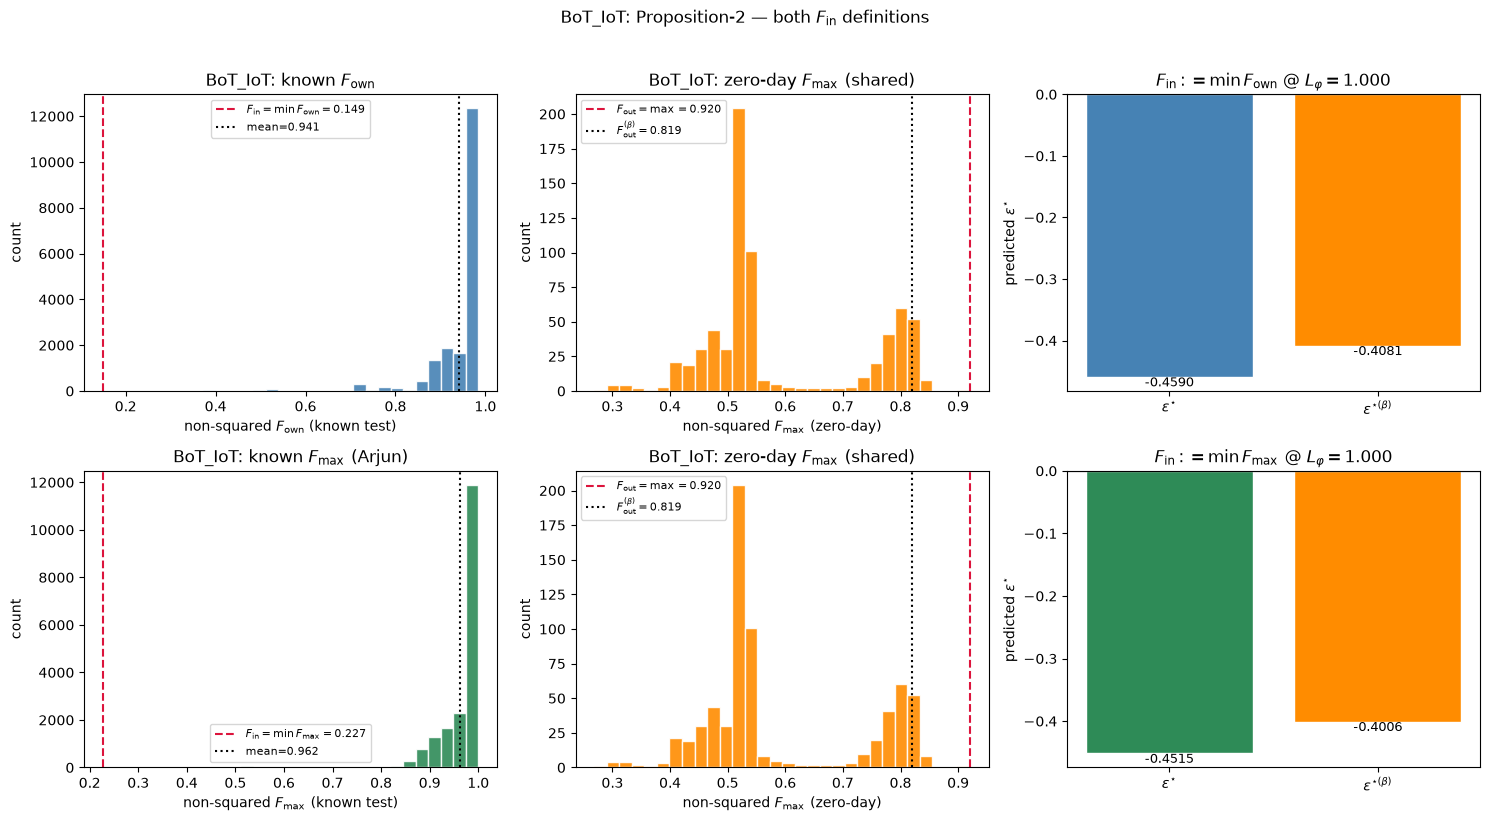

In [25]:
# plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ---------- row 0: F_in = min F_own ----------
axes[0, 0].hist(f_own, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
axes[0, 0].axvline(F_in_own, color="crimson", linestyle="--", label=fr"$F_{{\mathrm{{in}}}}=\min F_{{\mathrm{{own}}}}={F_in_own:.3f}$")
axes[0, 0].axvline(F_in_own_mean, color="black", linestyle=":", label=fr"mean={F_in_own_mean:.3f}")
axes[0, 0].set_xlabel(r"non-squared $F_{\mathrm{own}}$ (known test)")
axes[0, 0].set_ylabel("count")
axes[0, 0].set_title(rf"{dataset}: known $F_{{\mathrm{{own}}}}$")
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(f_max_zero, bins=30, color="darkorange", edgecolor="white", alpha=0.9)
axes[0, 1].axvline(F_out, color="crimson", linestyle="--", label=fr"$F_{{\mathrm{{out}}}}=\max={F_out:.3f}$")
axes[0, 1].axvline(F_out_beta, color="black", linestyle=":", label=fr"$F_{{\mathrm{{out}}}}^{{(\beta)}}={F_out_beta:.3f}$")
axes[0, 1].set_xlabel(r"non-squared $F_{\max}$ (zero-day)")
axes[0, 1].set_ylabel("count")
axes[0, 1].set_title(rf"{dataset}: zero-day $F_{{\max}}$ (shared)")
axes[0, 1].legend(fontsize=8)

vals_own = [eps_star_own, eps_star_beta_own]
axes[0, 2].bar(
    [r"$\varepsilon^{\star}$", rf"$\varepsilon^{{\star(\beta)}}$"],
    vals_own,
    color=["steelblue", "darkorange"],
    edgecolor="white",
)
axes[0, 2].axhline(0.0, color="black", linewidth=0.8)
axes[0, 2].set_ylabel(r"predicted $\varepsilon^{\star}$")
axes[0, 2].set_title(rf"$F_{{\mathrm{{in}}}}:=\min F_{{\mathrm{{own}}}}$ @ $L_\varphi={L_phi:.3f}$")
for i, v in enumerate(vals_own):
    axes[0, 2].text(i, v, f"{v:.4f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

# ---------- row 1: F_in = min F_max (Arjun) ----------
axes[1, 0].hist(f_max_known, bins=30, color="seagreen", edgecolor="white", alpha=0.9)
axes[1, 0].axvline(F_in_fmax, color="crimson", linestyle="--", label=fr"$F_{{\mathrm{{in}}}}=\min F_{{\max}}={F_in_fmax:.3f}$")
axes[1, 0].axvline(F_in_fmax_mean, color="black", linestyle=":", label=fr"mean={F_in_fmax_mean:.3f}")
axes[1, 0].set_xlabel(r"non-squared $F_{\max}$ (known test)")
axes[1, 0].set_ylabel("count")
axes[1, 0].set_title(rf"{dataset}: known $F_{{\max}}$ (Arjun)")
axes[1, 0].legend(fontsize=8)

axes[1, 1].hist(f_max_zero, bins=30, color="darkorange", edgecolor="white", alpha=0.9)
axes[1, 1].axvline(F_out, color="crimson", linestyle="--", label=fr"$F_{{\mathrm{{out}}}}=\max={F_out:.3f}$")
axes[1, 1].axvline(F_out_beta, color="black", linestyle=":", label=fr"$F_{{\mathrm{{out}}}}^{{(\beta)}}={F_out_beta:.3f}$")
axes[1, 1].set_xlabel(r"non-squared $F_{\max}$ (zero-day)")
axes[1, 1].set_ylabel("count")
axes[1, 1].set_title(rf"{dataset}: zero-day $F_{{\max}}$ (shared)")
axes[1, 1].legend(fontsize=8)

vals_fmax = [eps_star_fmax, eps_star_beta_fmax]
axes[1, 2].bar(
    [r"$\varepsilon^{\star}$", rf"$\varepsilon^{{\star(\beta)}}$"],
    vals_fmax,
    color=["seagreen", "darkorange"],
    edgecolor="white",
)
axes[1, 2].axhline(0.0, color="black", linewidth=0.8)
axes[1, 2].set_ylabel(r"predicted $\varepsilon^{\star}$")
axes[1, 2].set_title(rf"$F_{{\mathrm{{in}}}}:=\min F_{{\max}}$ @ $L_\varphi={L_phi:.3f}$")
for i, v in enumerate(vals_fmax):
    axes[1, 2].text(i, v, f"{v:.4f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

fig.suptitle(rf"{dataset}: Proposition-2 — both $F_{{\mathrm{{in}}}}$ definitions", y=1.02)
plt.tight_layout()
plt.show()

In [26]:
prop2_df = pd.DataFrame({
    "quantity": [
        "F_out (max F_max zero)",
        f"F_out_beta (q={1.0-BETA:g})",
        "F_out_mean",
        "p",
        "L_phi",
        "n_known",
        "n_zero",

        # F_in with f_own definition
        "F_in_own (min F_own)",
        "F_in_own_mean",
        "F_in_own_p05",
        "F_in_own_p50",
        "d_in_own",
        "d_out",
        "Delta_own",
        "eps_star_own",
        "Delta_beta_own",
        "eps_star_beta_own",
        "A5_own",
        "A5_beta_own",
        "F_in_own_gt_F_out",

        # F_in with f_max (Arjun's) definition
        "F_in_fmax (min F_max)",
        "F_in_fmax_mean",
        "F_in_fmax_p05",
        "F_in_fmax_p50",
        "d_in_fmax",
        "Delta_fmax",
        "eps_star_fmax",
        "Delta_beta_fmax",
        "eps_star_beta_fmax",
        "A5_fmax",
        "A5_beta_fmax",
        "F_in_fmax_gt_F_out",
    ],
    "value": [
        F_out, F_out_beta, F_out_mean,
        p, L_phi, len(f_own), len(f_max_zero),
        F_in_own, F_in_own_mean, F_in_own_p05, F_in_own_p50,
        d_in_own, d_out, Delta_own, eps_star_own,
        Delta_beta_own, eps_star_beta_own,
        sep_ok_own, sep_ok_beta_own, bool(F_in_own > F_out),
        F_in_fmax, F_in_fmax_mean, F_in_fmax_p05, F_in_fmax_p50,
        d_in_fmax, Delta_fmax, eps_star_fmax,
        Delta_beta_fmax, eps_star_beta_fmax,
        sep_ok_fmax, sep_ok_beta_fmax, bool(F_in_fmax > F_out),
    ],
})
prop2_df

,quantity,value
0,F_out (max F_max zero),0.920122
1,F_out_beta (q=0.95),0.819334
2,F_out_mean,0.587241
3,p,0.01
4,L_phi,1.0
5,n_known,18591
6,n_zero,683
7,F_in_own (min F_own),0.149367
8,F_in_own_mean,0.940599
9,F_in_own_p05,0.838192


## Prototypes


In [27]:
proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

,class,dim,trace
0,DDoS,256,1.0
1,DoS,256,1.0
2,Normal,256,1.0
3,Reconnaissance,256,1.0


## Logging


In [28]:
# save Proposition-2 artifact
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "p": float(p),
    "L_phi": float(L_phi),
    "L_phi_analytic": float(L_phi_analytic),
    "L_phi_estimated": float(L_phi_estimated),
    "L_phi_percentile": float(L_phi_percentile),
    "beta": float(BETA),
    "F_out": float(F_out),
    "F_out_beta": float(F_out_beta),
    "F_out_mean": float(F_out_mean),
    "d_out": float(d_out),
    # f_own definition
    "F_in_own": float(F_in_own),
    "F_in_own_mean": float(F_in_own_mean),
    "Delta_own": float(Delta_own),
    "eps_star_own": float(eps_star_own),
    "Delta_beta_own": float(Delta_beta_own),
    "eps_star_beta_own": float(eps_star_beta_own),
    "A5_own": bool(sep_ok_own),
    "A5_beta_own": bool(sep_ok_beta_own),
    # f_max / Arjun definition
    "F_in_fmax": float(F_in_fmax),
    "F_in_fmax_mean": float(F_in_fmax_mean),
    "Delta_fmax": float(Delta_fmax),
    "eps_star_fmax": float(eps_star_fmax),
    "Delta_beta_fmax": float(Delta_beta_fmax),
    "eps_star_beta_fmax": float(eps_star_beta_fmax),
    "A5_fmax": bool(sep_ok_fmax),
    "A5_beta_fmax": bool(sep_ok_beta_fmax),
    "n_known": int(len(f_own)),
    "n_zero": int(len(f_max_zero)),
    "f_own": f_own.tolist(),
    "f_max_known": f_max_known.tolist(),
    "f_max_zero": f_max_zero.tolist(),
    "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
    "lphi_path": str(lphi_path) if lphi_path is not None else None,
}

prop2_path = out_dir / f"{NOTEBOOK_NAME}-prop2.pt"
torch.save(artifact, prop2_path)
print("published Proposition-2 artifact:", prop2_path.resolve())

published Proposition-2 artifact: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/BoT-IoT/18.fin-fout-epsstar_bot-iot-prop2.pt


In [29]:
# write log (final)
log_path = write_history_log(
    history if history else {
        "eps_star_own": [float(eps_star_own)],
        "eps_star_fmax": [float(eps_star_fmax)],
    },
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": split_prefix,
        "target_col": target_col,
        "n_train": len(X_train),
        "n_test": int(len(to_np_y(y_test))),
        "n_zero": int(len(X_zero)),
        "per_class_cap": PER_CLASS_CAP if SUBSET else None,
        "zero_cap": ZERO_CAP if ZERO_SUBSET else None,
        "class_names": list(class_names),

        ## quantum model
        "noise_rate": float(p),
        "num_layers": int(num_layers),
        "num_qubits": int(num_qubits),
        "num_classes": int(num_classes),

        ## Proposition 2
        "L_phi": float(L_phi),
        "beta": float(BETA),
        "F_out": float(F_out),
        "F_out_beta": float(F_out_beta),

        ## Proposition 2: F_in (from f_own)
        "F_in_own": float(F_in_own),
        "Delta_own": float(Delta_own),
        "eps_star_own": float(eps_star_own),
        "eps_star_beta_own": float(eps_star_beta_own),
        "A5_own": bool(sep_ok_own),

        ## Proposition 2: F_in (from f_max)
        "F_in_fmax": float(F_in_fmax),
        "Delta_fmax": float(Delta_fmax),
        "eps_star_fmax": float(eps_star_fmax),
        "eps_star_beta_fmax": float(eps_star_beta_fmax),
        "A5_fmax": bool(sep_ok_fmax),

        "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
        "lphi_path": str(lphi_path) if lphi_path is not None else None,
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/18.fin-fout-epsstar_bot-iot.log
